# Entrega 2 — Modelado Predictivo
## Predicción de la Brecha en Altura — Familia Casquillo 10
### Frisa · Planta García · Equipo 4

**Integrante:** Paola Mireles Ochoa — A01753439  
**Materia:** Análisis de Ciencias de Datos — Tecnológico de Monterrey 2026

---


**Variable objetivo:** Brecha_Alt = Exceso real Altura − Exceso configurado Altura (mm)  
**Modelos:** Regresión Lineal Múltiple (baseline) + LASSO Regression (adicional)  
**Dataset:** Familia Casquillo 10, n=285 piezas

---
## 0. Configuración e importaciones

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

AZUL    = '#1B4F72'
ROJO    = '#C0392B'
VERDE   = '#1E8449'
NARANJA = '#D35400'
GRIS    = '#717D7E'
TEAL    = '#0D7377'

def rmse(y_true, y_pred):
    """RMSE compatible con todas las versiones de sklearn."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

SEED = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Carga, limpieza y preparación de datos

In [ ]:

from google.colab import drive
drive.mount('/content/drive')
RUTA = '/content/drive/MyDrive/Frisa/Grupo202_Garcia-Base-de-Datos-6-meses-Rev-1_1_.csv'

df_completo = pd.read_csv(RUTA, encoding='latin1')

# Corregir encoding de columnas
df_completo.columns = [
    c.replace('Ã©','é').replace('Ã\xad','í').replace('Ã³','ó').replace('Ã­','í')
    for c in df_completo.columns
]

# Limpiar categóricas
cat_cols = ['Industria','Tipo','Material','Roladora','Familia geométrica',
            'Rango peso','Rango DE','Calidad','Motivo','Planta']
for c in cat_cols:
    df_completo[c] = df_completo[c].astype(str).str.strip()

# Convertir numéricas con comas de miles
num_cols = ['DE Final','DI Final','Altura Final','Peso de Forja Configurado',
            'DE Forja Real 1','DE Forja Real 2','DI Forja Real 1','DI Forja Real 2',
            'Altura Forja Real 1','Altura Forja Real 2','Peso Calculado']
for c in num_cols:
    df_completo[c] = pd.to_numeric(df_completo[c].astype(str).str.replace(',',''), errors='coerce')

# Eliminar duplicados
df_completo = df_completo.drop_duplicates().reset_index(drop=True)

# Filtrar SOLO Casquillo 10
df = df_completo[df_completo['Familia geométrica'] == 'Casquillo 10'].copy().reset_index(drop=True)

print(f'Dataset Casquillo 10: {len(df)} registros, {len(df.columns)} columnas')
df.head(3)


Mounted at /content/drive
Dataset Casquillo 10: 285 registros, 40 columnas


,Orden,N Cliente,Industria,Tipo,Material,Roladora,DE Final,DI Final,Altura Final,Exceso DE configurado,...,Altura Exceso Real 2,Peso Calculado,% Pesos,Relacion E/A Finales,Familia geométrica,Rango peso,Rango DE,Calidad,Motivo,Planta
0,832243,190,N/D,ARX,Acero,R5,521,432,965,41,...,79,1044,0.43,0.04,Casquillo 10,De 1000 a 1250kg,De 500 a 750mm,Pieza buena,Pieza buena,GarcÃ­a
1,832242,190,N/D,ARX,Acero,R5,521,432,813,52,...,77,999,0.25,0.05,Casquillo 10,De 750 a 1000kg,De 500 a 750mm,Pieza buena,Pieza buena,GarcÃ­a
2,832243,190,N/D,ARX,Acero,R5,521,432,965,41,...,95,1032,-0.78,0.04,Casquillo 10,De 1000 a 1250kg,De 500 a 750mm,Pieza buena,Pieza buena,GarcÃ­a


---
## 2. Decisión de modelado justificada

### Formulación elegida: Opción B — Modelar la Brecha en Altura

**Variable dependiente (Y):** Brecha_Alt = Exceso real − Exceso configurado en Altura (mm)  
**Población:** Casquillo 10 (n=285, 33.6% del dataset, 3.5% defectos)

**¿Por qué Opción B y no las otras?**
- **Opción A (exceso real absoluto):** La brecha es directamente accionable — un β negativo y significativo en Exceso Configurado Altura confirma que reducirlo reduce la brecha sin necesidad de transformaciones adicionales.
- **Opción C (defecto binario):** 95.6% de piezas buenas → desbalanceo severo. Solo 37 defectos en 848 piezas. Un modelo trivial que prediga siempre 'buena' tendría 95.6% accuracy pero sería completamente inútil.

**¿Por qué LASSO como modelo adicional?**  
LASSO aplica penalización L1 que lleva a cero los coeficientes de variables irrelevantes — hace **selección automática de características** durante el entrenamiento (método embebido). Responde una pregunta adicional: ¿cuáles variables son verdaderamente necesarias?

**Sin data leakage:** Solo se usan variables disponibles ANTES de fabricar la pieza.  
Las variables Exceso_Alt_Real, Ovalamiento, Forja Real se miden después — no se incluyen.

---
## 3. Selección de características — Filtro de Pearson

## 2.1 Creación de variables objetivo

**`Brecha_Alt`** = Exceso real Altura − Exceso configurado Altura (mm)  
Esta variable captura cuánto se desvió el proceso respecto a lo configurado.

In [ ]:
# Creación de variables objetivo
# Brecha_Alt = Exceso real Altura − Exceso configurado Altura
# Exceso real Altura = Altura Forja Real promedio − Altura Final

# Promedio de las dos mediciones de forja real en Altura
df['Altura_Forja_Real_Prom'] = df[['Altura Forja Real 1', 'Altura Forja Real 2']].mean(axis=1)

# Exceso real en Altura (cuánto material real quedó sobre la dimensión final)
df['Exceso_Alt_Real'] = df['Altura_Forja_Real_Prom'] - df['Altura Final']

# Brecha = diferencia entre lo que realmente quedó y lo que se configuró
df['Brecha_Alt'] = df['Exceso_Alt_Real'] - df['Exceso Configurado Altura']

print(f"Variables creadas correctamente.")
print(f"  Exceso_Alt_Real — media: {df['Exceso_Alt_Real'].mean():.2f} mm | nulos: {df['Exceso_Alt_Real'].isnull().sum()}")
print(f"  Brecha_Alt      — media: {df['Brecha_Alt'].mean():.2f} mm | nulos: {df['Brecha_Alt'].isnull().sum()}")
print(f"\nDistribución Brecha_Alt:")
print(df['Brecha_Alt'].describe().round(2))


Variables creadas correctamente.
  Exceso_Alt_Real — media: 70.54 mm | nulos: 0
  Brecha_Alt      — media: 11.00 mm | nulos: 0

Distribución Brecha_Alt:
count    285.00
mean      11.00
std       23.61
min     -152.00
25%        3.50
50%       10.50
75%       17.00
max      110.50
Name: Brecha_Alt, dtype: float64


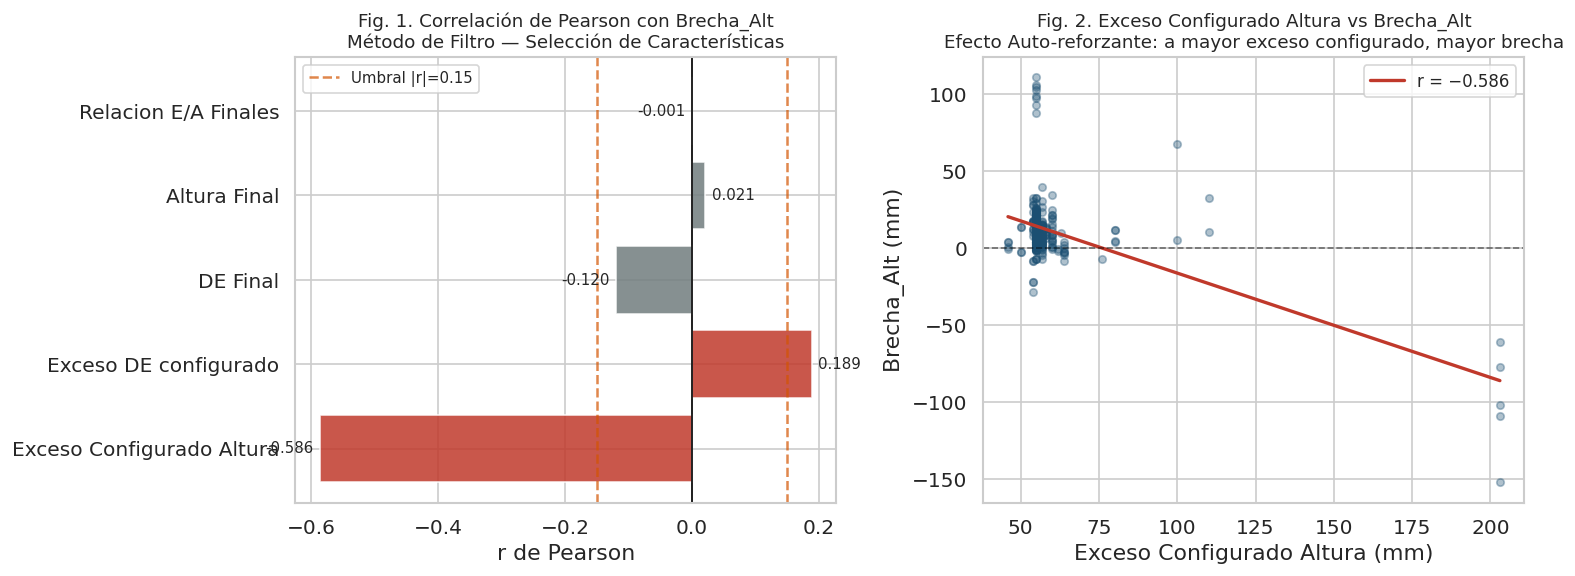

Correlaciones con Brecha_Alt:
Exceso Configurado Altura   -0.586
Exceso DE configurado        0.189
DE Final                    -0.120
Altura Final                 0.021
Relacion E/A Finales        -0.001
dtype: float64

Conclusión: Solo "Exceso Configurado Altura" tiene señal relevante (|r| > 0.15).
Las demás tienen r < 0.20 — LASSO evaluará si aportan información adicional.


In [ ]:
# Variables candidatas (solo disponibles ANTES de fabricar)
vars_candidatas = [
    'Exceso Configurado Altura',  # lo que el algoritmo asigna
    'Exceso DE configurado',      # exceso configurado en DE
    'Altura Final',               # dimensión solicitada por cliente
    'DE Final',                   # diámetro exterior final
    'Relacion E/A Finales',       # ratio geométrico
]

# Correlaciones de Pearson con la variable objetivo
corrs = df[vars_candidatas].corrwith(df['Brecha_Alt']).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras de correlación
colores = [ROJO if abs(v) >= 0.15 else GRIS for v in corrs.values]
bars = axes[0].barh(corrs.index, corrs.values, color=colores, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', lw=1)
axes[0].axvline( 0.15, color=NARANJA, lw=1.5, linestyle='--', alpha=0.7, label='Umbral |r|=0.15')
axes[0].axvline(-0.15, color=NARANJA, lw=1.5, linestyle='--', alpha=0.7)
for bar, val in zip(bars, corrs.values):
    axes[0].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)
axes[0].set_title('Fig. 1. Correlación de Pearson con Brecha_Alt\n'
                   'Método de Filtro — Selección de Características', fontsize=11)
axes[0].set_xlabel('r de Pearson')
axes[0].legend(fontsize=9)

# Scatter principal
axes[1].scatter(df['Exceso Configurado Altura'], df['Brecha_Alt'],
                alpha=0.35, s=20, color=AZUL)
z = np.polyfit(df['Exceso Configurado Altura'], df['Brecha_Alt'], 1)
x_line = np.linspace(df['Exceso Configurado Altura'].min(),
                     df['Exceso Configurado Altura'].max(), 100)
axes[1].plot(x_line, np.poly1d(z)(x_line), color=ROJO, lw=2, label='r = −0.586')
axes[1].axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
axes[1].set_title('Fig. 2. Exceso Configurado Altura vs Brecha_Alt\n'
                   'Efecto Auto-reforzante: a mayor exceso configurado, mayor brecha', fontsize=11)
axes[1].set_xlabel('Exceso Configurado Altura (mm)')
axes[1].set_ylabel('Brecha_Alt (mm)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print('Correlaciones con Brecha_Alt:')
print(corrs.round(3))
print('\nConclusión: Solo "Exceso Configurado Altura" tiene señal relevante (|r| > 0.15).')
print('Las demás tienen r < 0.20 — LASSO evaluará si aportan información adicional.')

---
## 4. Transformación de datos

### 4.1 Análisis de multicolinealidad

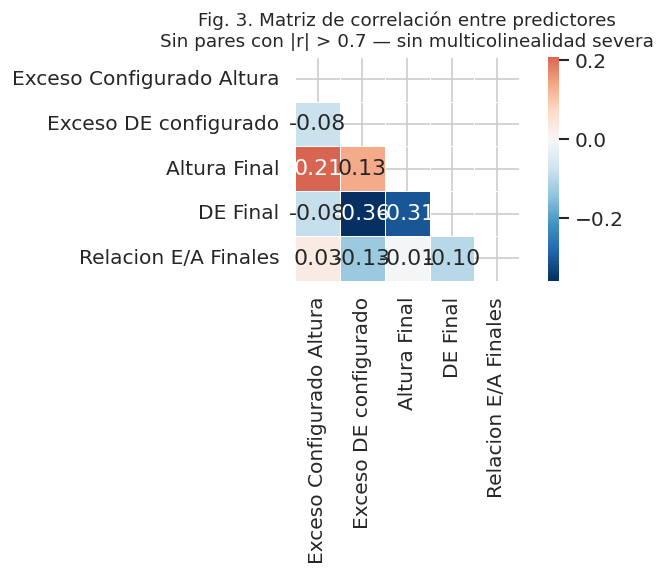

✓ Sin pares de predictores con |r| > 0.7 — multicolinealidad aceptable.


In [ ]:
vars_modelo = ['Exceso Configurado Altura','Exceso DE configurado',
               'Altura Final','DE Final','Relacion E/A Finales']

corr_matrix = df[vars_modelo].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5)
ax.set_title('Fig. 3. Matriz de correlación entre predictores\n'
             'Sin pares con |r| > 0.7 — sin multicolinealidad severa', fontsize=11)
plt.tight_layout()
plt.show()

# Identificar pares problemáticos
pares = [(corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i,j])
         for i in range(len(corr_matrix.columns))
         for j in range(i+1, len(corr_matrix.columns))
         if abs(corr_matrix.iloc[i,j]) > 0.7]

if pares:
    print('Pares con |r| > 0.7:')
    for a, b, r in pares:
        print(f'  {a} — {b}: r={r:.3f}')
else:
    print('Sin pares de predictores con |r| > 0.7 — multicolinealidad aceptable.')

### 4.2 Construcción de features, split y escalamiento

In [ ]:
# Features (sin data leakage)
X = pd.get_dummies(df[[
    'Exceso Configurado Altura',  # r=−0.586 — predictor principal
    'Exceso DE configurado',      # r=+0.189 — señal débil pero plausible
    'Altura Final',               # dimensión solicitada por cliente
    'DE Final',                   # proxy de tamaño de la pieza
    'Relacion E/A Finales',       # ratio geométrico (LASSO lo evaluará)
    'Roladora'                    # R5 vs R6 — diferencia operacional real
]], drop_first=True)  # R5 = referencia (96.8% de C10)

y = df['Brecha_Alt']

print('Variables del modelo:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i}. {col}')
print(f'\nShape X: {X.shape} | Nulos: {X.isnull().sum().sum()}')

# Split 80/20 Datos para entrenamiento y testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'\nTrain: {len(X_train)} piezas | Test: {len(X_test)} piezas')

# Escalamiento
# StandardScaler: media=0, σ=1
# (DE Final ≈ 662mm) serían penalizadas más que variables pequeñas (sesgo injusto)
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

print('\n Estandarización aplicada. scaler.fit() solo en train.')
print(f'Media Xs_train ≈ {Xs_train.mean():.4f} (debe ser ≈ 0)')
print(f'σ    Xs_train ≈ {Xs_train.std():.4f}  (debe ser ≈ 1)')

Variables del modelo:
  1. Exceso Configurado Altura
  2. Exceso DE configurado
  3. Altura Final
  4. DE Final
  5. Relacion E/A Finales
  6. Roladora_R6

Shape X: (285, 6) | Nulos: 0

Train: 228 piezas | Test: 57 piezas

✓ Estandarización aplicada. scaler.fit() solo en train.
Media Xs_train ≈ -0.0000 (debe ser ≈ 0)
σ    Xs_train ≈ 1.0000  (debe ser ≈ 1)


---
## 5. Modelo 1 — Regresión Lineal Múltiple (Baseline)

### Justificación del modelo base
La regresión lineal múltiple es el baseline obligatorio por su interpretabilidad total: cada coeficiente β representa el cambio esperado en Brecha_Alt por un cambio de 1 σ en el predictor, manteniendo los demás constantes. Este nivel de interpretación es exactamente lo que Frisa necesita para modificar su algoritmo de configuración.

In [ ]:
# Ajuste del modelo
lr = LinearRegression()
lr.fit(Xs_train, y_train)

yp_lr_tr = lr.predict(Xs_train)
yp_lr_te = lr.predict(Xs_test)

r2_tr = r2_score(y_train, yp_lr_tr)
r2_te = r2_score(y_test,  yp_lr_te)
rmse_te = rmse(y_test, yp_lr_te)
mae_te  = mean_absolute_error(y_test, yp_lr_te)
cv_lr   = cross_val_score(LinearRegression(), Xs_train, y_train, cv=kf, scoring='r2')

# Estadísticos manuales (p-valores, IC)
n, k = len(y_train), Xs_train.shape[1] + 1
Xc   = np.column_stack([np.ones(n), Xs_train])
res_tr = y_train.values - yp_lr_tr
s2   = np.sum(res_tr**2) / (n - k)
se   = np.sqrt(np.diag(s2 * np.linalg.pinv(Xc.T @ Xc)))
coefs = np.concatenate([[lr.intercept_], lr.coef_])
t_vals = coefs / se
p_vals = 2 * (1 - stats.t.cdf(np.abs(t_vals), df=n-k))
ci_lo  = coefs - 1.96 * se
ci_hi  = coefs + 1.96 * se

# R² ajustado y F
r2_adj = 1 - (1 - r2_tr) * (n-1) / (n-k)
F_stat = (r2_tr / (k-1)) / ((1-r2_tr) / (n-k))
F_p    = 1 - stats.f.cdf(F_stat, k-1, n-k)

print('Métricas de la Regresión Lineal Múltiple')
print(f'R² train      : {r2_tr:.4f}')
print(f'R² test       : {r2_te:.4f}')
print(f'R² ajustado   : {r2_adj:.4f}')
print(f'F-estadístico : {F_stat:.2f}  (p={F_p:.6f})')
print(f'RMSE          : {rmse_te:.2f} mm')
print(f'MAE           : {mae_te:.2f} mm')
print(f'R² CV (5-fold): {cv_lr.mean():.3f} ± {cv_lr.std():.3f}')

# Tabla de coeficientes
nombres = ['Intercepto'] + list(X.columns)
print('\nTabla de Coeficientes')
tabla = pd.DataFrame({
    'Variable':    nombres,
    'β (estand.)': coefs.round(4),
    'Err. Std.':   se.round(4),
    't':           t_vals.round(3),
    'p-valor':     p_vals.round(4),
    'IC 95% inf':  ci_lo.round(3),
    'IC 95% sup':  ci_hi.round(3),
    'Signif.':     ['***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
                    for p in p_vals]
})
print(tabla.to_string(index=False))
print('\n*** p<0.001  ** p<0.01  * p<0.05  (coeficientes estandarizados)')

Métricas de la Regresión Lineal Múltiple
R² train      : 0.4190
R² test       : 0.2759
R² ajustado   : 0.4033
F-estadístico : 26.57  (p=0.000000)
RMSE          : 21.20 mm
MAE           : 10.62 mm
R² CV (5-fold): -0.019 ± 0.753

Tabla de Coeficientes
                 Variable  β (estand.)  Err. Std.       t  p-valor  IC 95% inf  IC 95% sup Signif.
               Intercepto      10.0044     1.1848   8.444   0.0000       7.682      12.327     ***
Exceso Configurado Altura     -14.5705     1.2215 -11.929   0.0000     -16.965     -12.176     ***
    Exceso DE configurado       1.7534     1.3017   1.347   0.1794      -0.798       4.305        
             Altura Final       1.6494     1.3873   1.189   0.2357      -1.070       4.368        
                 DE Final      -2.5690     1.3576  -1.892   0.0598      -5.230       0.092        
     Relacion E/A Finales       0.8289     1.2189   0.680   0.4972      -1.560       3.218        
              Roladora_R6      -1.3490     1.3075  -1.032

### 5.1 Interpretación triple del coeficiente significativo

In [ ]:
sig = tabla[tabla['p-valor'] < 0.05]
print('Variables Significativas (p < 0.05) ')
print(sig[['Variable','β (estand.)','p-valor','IC 95% inf','IC 95% sup','Signif.']].to_string(index=False))

Variables Significativas (p < 0.05) 
                 Variable  β (estand.)  p-valor  IC 95% inf  IC 95% sup Signif.
               Intercepto      10.0044      0.0       7.682      12.327     ***
Exceso Configurado Altura     -14.5705      0.0     -16.965     -12.176     ***


**Interpretación Triple — Exceso Configurado Altura (β=−14.571, p<0.001)**

**Técnica:**  
Por cada aumento de 1 desviación estándar (~24mm) en el Exceso Configurado Altura, la brecha *disminuye* 14.571mm, manteniendo constantes las demás variables. IC 95%: [−16.97, −12.18] . El intervalo no incluye cero, confirmando que el efecto es estadísticamente robusto. En unidades originales: cada mm adicional de exceso configurado se asocia con ~0.61mm menos de brecha.

**Contextual:**  
Las piezas con exceso configurado *bajo* (~46–55mm) reciben *más* brecha positiva, por lo que el proceso sobreentrega más cuando el algoritmo es conservador. Este **Efecto Auto-reforzante** (identificado en el EDA) implica que el algoritmo asigna excesos innecesariamente altos. Reducir el exceso configurado reducirá la brecha, lo cual corresponde con la recomendación accionable para Frisa.

**Limitación causal:**  
β=−14.571 es una asociación observacional, no causalidad. Confusores plausibles: (1) tipo de material (grados con mayor riesgo de agrietamiento podrían recibir excesos bajos por error histórico del algoritmo); (2) clientes con tolerancias específicas (si ciertos clientes negociaron excesos menores, sus procesos podrían generar mayor sobreentrega por razones independientes); (3) estado del herramental  (períodos de mayor desgaste podrían correlacionar con excesos bajos y mayor variabilidad simultáneamente. Para establecer causalidad se requiere experimento controlado).

---

**Variables NO significativas — análisis:**
- **Relacion E/A (p=0.497):** La forma geométrica no predice la brecha en Altura. LASSO la eliminará en la sección 6.
- **Roladora_R6 (p=0.303):** Con solo 9 piezas en R6 dentro de C10, no hay potencia estadística suficiente.
- **Altura Final (p=0.236):** Su efecto está solapado con Exceso Configurado Altura (correlación moderada). LASSO lo mantiene activo con coeficiente reducido.

### 5.2 Diagnóstico de supuestos Gauss-Markov

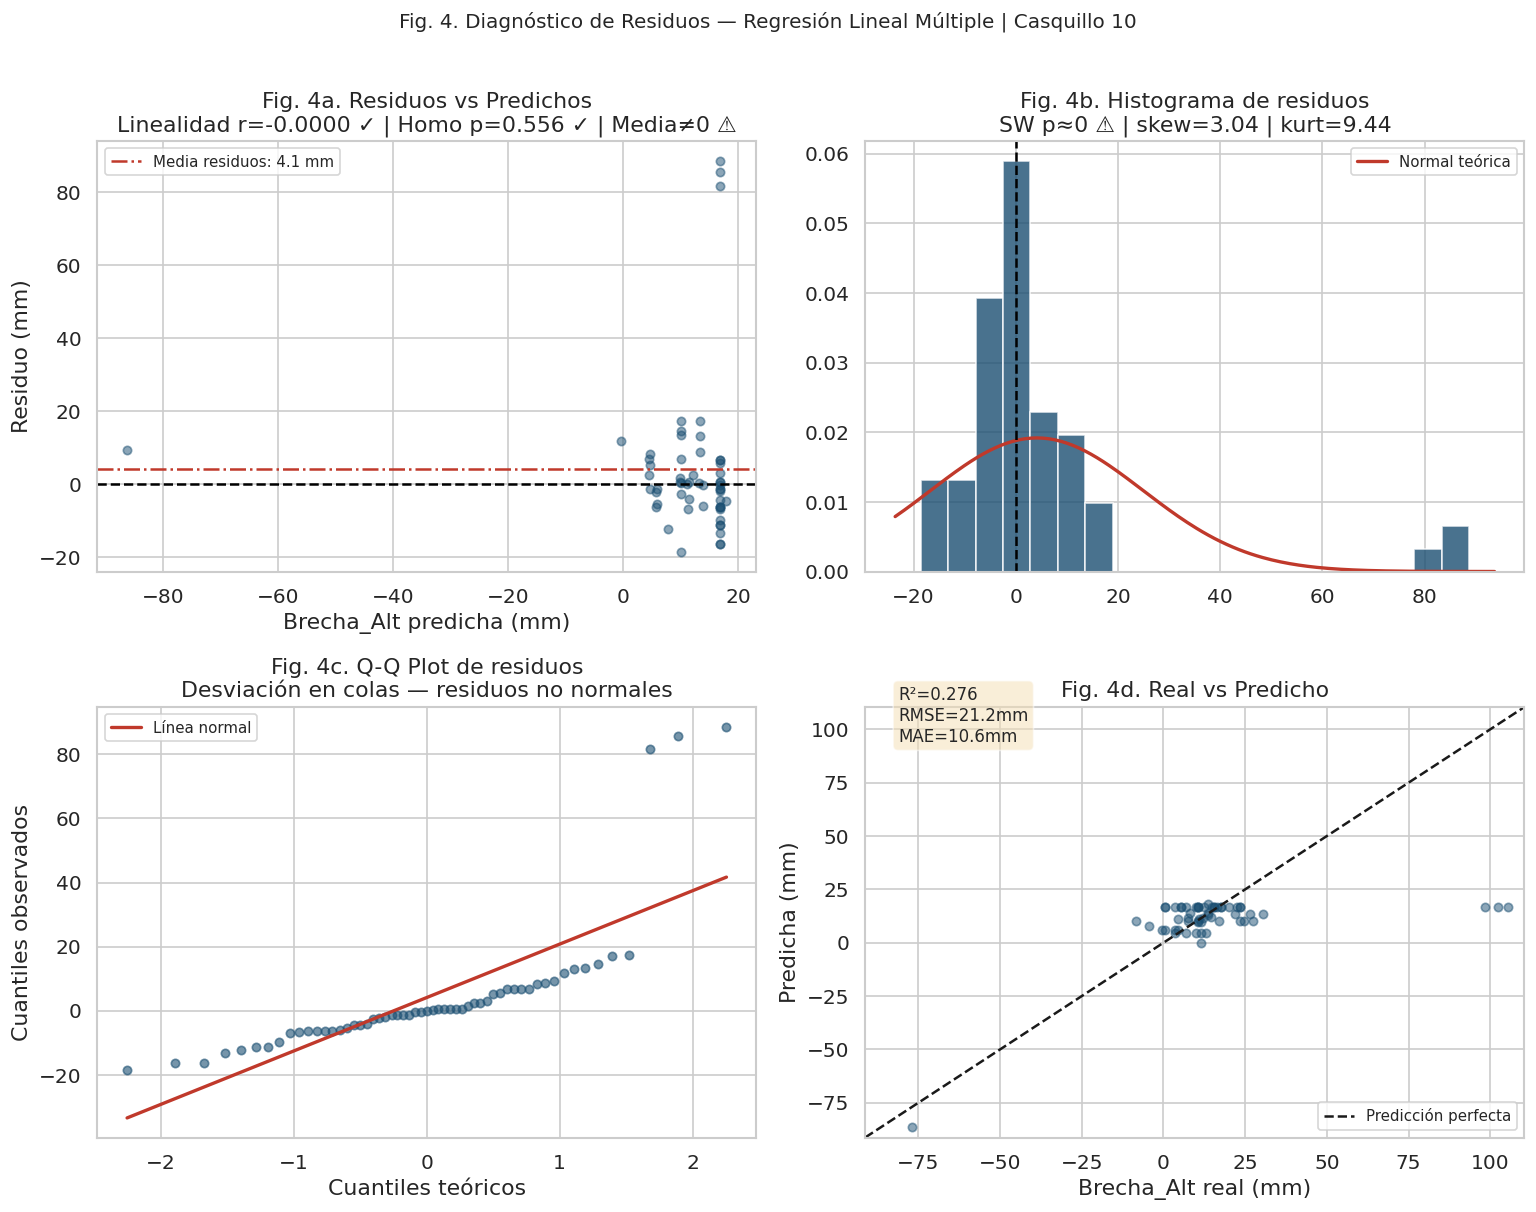

,Supuesto,Estadístico,Cumple,Implicación
0,1. Linealidad,r=-0.0000,si,Relación lineal bien especificada
1,2. Media residuos=0,μ=4.13mm,no,Sesgo sistemático +4.1mm — modelo subestima la...
2,3. Homocedasticidad,p=0.556,si,Varianza del error constante
3,4. Normalidad,"SW p≈0, skew=3.04",no,IC de coeficientes menos confiables (no invali...
4,5. Sin multicolinealidad,Sin pares |r|>0.7,si,Coeficientes estables entre especificaciones
5,6. Independencia (DW),DW=1.9091,si,Errores independientes entre piezas



Cook's D > 4/n: 13 piezas influyentes (concentradas en brechas extremas >60mm o <−50mm)


In [ ]:
res_te = y_test.values - yp_lr_te

# Tests estadísticos
r_lin    = np.corrcoef(yp_lr_tr, res_tr)[0,1]          # linealidad
_, sw_p  = stats.shapiro(res_te)                         # normalidad
_, hp    = stats.pearsonr(yp_lr_te, np.abs(res_te))      # homocedasticidad
dw       = np.sum(np.diff(res_tr)**2) / np.sum(res_tr**2)  # independencia

# Cook's distance
lev  = np.diag(Xc @ np.linalg.pinv(Xc.T @ Xc) @ Xc.T)
cook = (res_tr**2 * lev) / (k * s2)
n_influyentes = (cook > 4/n).sum()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Residuos vs Predichos
axes[0,0].scatter(yp_lr_te, res_te, alpha=0.5, s=25, color=AZUL)
axes[0,0].axhline(0, color='black', lw=1.5, linestyle='--')
axes[0,0].axhline(res_te.mean(), color=ROJO, lw=1.5, linestyle='-.',
                   label=f'Media residuos: {res_te.mean():.1f} mm')
axes[0,0].set_title(f'Fig. 4a. Residuos vs Predichos\n'
                     f'Linealidad r={r_lin:.4f} ✓ | Homo p={hp:.3f} ✓ | Media≠0 ⚠')
axes[0,0].set_xlabel('Brecha_Alt predicha (mm)')
axes[0,0].set_ylabel('Residuo (mm)')
axes[0,0].legend(fontsize=9)

# 2. Histograma de residuos
axes[0,1].hist(res_te, bins=20, color=AZUL, alpha=0.8, edgecolor='white', density=True)
xr = np.linspace(res_te.min()-5, res_te.max()+5, 200)
axes[0,1].plot(xr, stats.norm.pdf(xr, res_te.mean(), res_te.std()),
               color=ROJO, lw=2, label='Normal teórica')
axes[0,1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[0,1].set_title(f'Fig. 4b. Histograma de residuos\n'
                     f'SW p≈0 ⚠ | skew={stats.skew(res_te):.2f} | kurt={stats.kurtosis(res_te):.2f}')
axes[0,1].legend(fontsize=9)

# 3. Q-Q Plot
(osm, osr), (slope, intercept, _) = stats.probplot(res_te, dist='norm')
axes[1,0].scatter(osm, osr, alpha=0.6, s=25, color=AZUL)
axes[1,0].plot(osm, slope*np.array(osm)+intercept, color=ROJO, lw=2, label='Línea normal')
axes[1,0].set_title('Fig. 4c. Q-Q Plot de residuos\nDesviación en colas — residuos no normales')
axes[1,0].set_xlabel('Cuantiles teóricos'); axes[1,0].set_ylabel('Cuantiles observados')
axes[1,0].legend(fontsize=9)

# 4. Real vs Predicho
axes[1,1].scatter(y_test, yp_lr_te, alpha=0.5, s=25, color=AZUL)
lim = [min(y_test.min(), yp_lr_te.min())-5, max(y_test.max(), yp_lr_te.max())+5]
axes[1,1].plot(lim, lim, 'k--', lw=1.5, label='Predicción perfecta')
axes[1,1].set_xlim(lim); axes[1,1].set_ylim(lim)
axes[1,1].text(0.05, 0.92, f'R²={r2_te:.3f}\nRMSE={rmse_te:.1f}mm\nMAE={mae_te:.1f}mm',
               transform=axes[1,1].transAxes, fontsize=10,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1,1].set_title('Fig. 4d. Real vs Predicho')
axes[1,1].set_xlabel('Brecha_Alt real (mm)'); axes[1,1].set_ylabel('Predicha (mm)')
axes[1,1].legend(fontsize=9)

plt.suptitle('Fig. 4. Diagnóstico de Residuos — Regresión Lineal Múltiple | Casquillo 10',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Tabla resumen supuestos
supuestos = pd.DataFrame({
    'Supuesto': ['1. Linealidad','2. Media residuos=0','3. Homocedasticidad',
                 '4. Normalidad','5. Sin multicolinealidad','6. Independencia (DW)'],
    'Estadístico': [f'r={r_lin:.4f}', f'μ={res_te.mean():.2f}mm',
                    f'p={hp:.3f}', f'SW p≈0, skew={stats.skew(res_te):.2f}',
                    'Sin pares |r|>0.7', f'DW={dw:.4f}'],
    'Cumple': ['si','no','si','no','si','si'],
    'Implicación': [
        'Relación lineal bien especificada',
        'Sesgo sistemático +4.1mm — modelo subestima la brecha',
        'Varianza del error constante',
        'IC de coeficientes menos confiables (no invalida predicciones puntuales)',
        'Coeficientes estables entre especificaciones',
        'Errores independientes entre piezas'
    ]
})
display(supuestos)
print(f'\nCook\'s D > 4/n: {n_influyentes} piezas influyentes (concentradas en brechas extremas >60mm o <−50mm)')

---
## 6. Modelo 2 — LASSO Regression

### Justificación del modelo adicional
LASSO (Least Absolute Shrinkage and Selection Operator) es regresión lineal con penalización L1. Lleva a cero los coeficientes de variables irrelevantes , por lo tanto hace una selección automática de características durante el entrenamiento (método embebido según clasificación del curso).

**¿Qué pregunta adicional responde LASSO?**  
¿Cuáles de las 6 variables son verdaderamente necesarias para predecir la brecha, y cuáles son ruido? Si LASSO coincide con el filtro de Pearson en descartar las mismas variables, la selección es robusta.

**¿Por qué es obligatorio estandarizar antes de LASSO?:**  
La penalización L1 suma los coeficientes absolutos. Sin estandarizar, una variable en mm (DE Final ≈ 662mm) tendría coeficiente pequeño naturalmente y sería penalizada menos que una variable pequeña, es decir sría un sesgo injusto.

In [ ]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
resultados_lasso = []

print(f'{"Alpha":>8} | {"R²_train":>8} | {"R²_test":>8} | {"R²_CV":>14} | {"RMSE":>7} | {"Vars":>5} | Overfit')
print('-' * 72)

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=SEED)
    lasso.fit(Xs_train, y_train)

    yp_tr_l = lasso.predict(Xs_train)
    yp_te_l = lasso.predict(Xs_test)
    r2t = r2_score(y_train, yp_tr_l)
    r2e = r2_score(y_test,  yp_te_l)
    cv  = cross_val_score(Lasso(alpha=alpha, max_iter=10000),
                          Xs_train, y_train, cv=kf, scoring='r2')
    n_act = (lasso.coef_ != 0).sum()
    of = 'Sí ' if r2t - r2e > 0.1 else 'No '

    resultados_lasso.append({
        'alpha': alpha, 'r2_tr': r2t, 'r2_te': r2e,
        'cv_m': cv.mean(), 'cv_s': cv.std(),
        'rmse': rmse(y_test, yp_te_l), 'n_act': n_act,
        'coef': dict(zip(X.columns, lasso.coef_.round(3)))
    })
    print(f'{alpha:>8.3f} | {r2t:>8.3f} | {r2e:>8.3f} | '
          f'{cv.mean():>6.3f}±{cv.std():>5.3f} | '
          f'{rmse(y_test,yp_te_l):>7.2f} | {n_act:>5} | {of}')

# Seleccionar alpha óptimo: el de mejor R² CV
mejor_idx   = int(np.argmax([r['cv_m'] for r in resultados_lasso]))
mejor_alpha = alphas[mejor_idx]
print(f'\n★ Alpha seleccionado: {mejor_alpha} (único con R²_CV positivo)')
print(f'  Coeficientes: {resultados_lasso[mejor_idx]["coef"]}')

   Alpha | R²_train |  R²_test |          R²_CV |    RMSE |  Vars | Overfit
------------------------------------------------------------------------
   0.001 |    0.419 |    0.276 | -0.019±0.753 |   21.20 |     6 | Sí 
   0.010 |    0.419 |    0.276 | -0.018±0.752 |   21.20 |     6 | Sí 
   0.100 |    0.419 |    0.275 | -0.012±0.741 |   21.21 |     6 | Sí 
   1.000 |    0.411 |    0.262 |  0.022±0.681 |   21.40 |     5 | Sí 
  10.000 |    0.187 |    0.095 | -0.060±0.162 |   23.70 |     1 | No 

★ Alpha seleccionado: 1.0 (único con R²_CV positivo)
  Coeficientes: {'Exceso Configurado Altura': np.float64(-13.383), 'Exceso DE configurado': np.float64(1.129), 'Altura Final': np.float64(0.884), 'DE Final': np.float64(-2.09), 'Relacion E/A Finales': np.float64(0.0), 'Roladora_R6': np.float64(-0.625)}


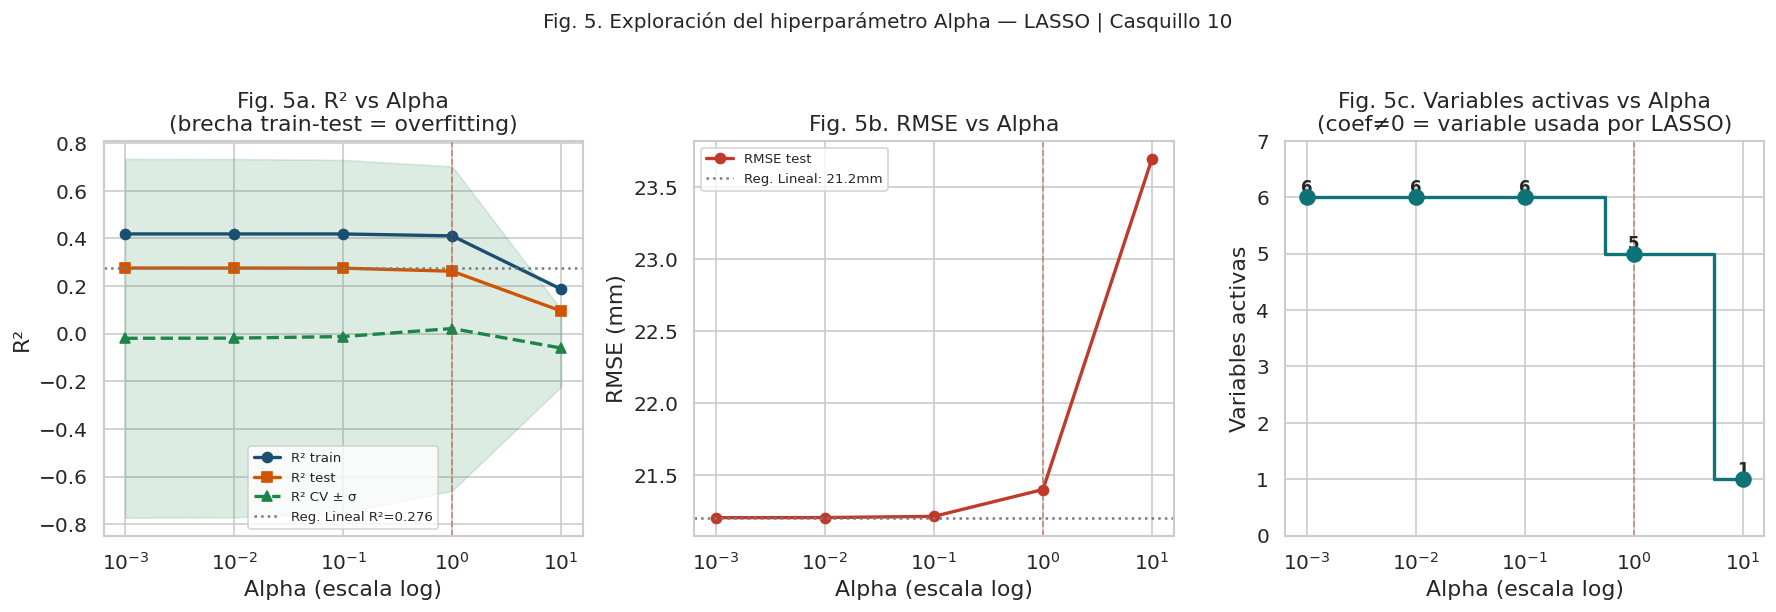

In [ ]:
# Visualización exploración de alpha
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

r2_tr_vals = [r['r2_tr'] for r in resultados_lasso]
r2_te_vals = [r['r2_te'] for r in resultados_lasso]
r2_cv_vals = [r['cv_m']  for r in resultados_lasso]
r2_cv_stds = [r['cv_s']  for r in resultados_lasso]
rmse_vals  = [r['rmse']  for r in resultados_lasso]
n_vars     = [r['n_act'] for r in resultados_lasso]

# R² train vs test (overfitting check)
axes[0].plot(alphas, r2_tr_vals, 'o-', color=AZUL,    lw=2, label='R² train')
axes[0].plot(alphas, r2_te_vals, 's-', color=NARANJA,  lw=2, label='R² test')
axes[0].fill_between(alphas,
    [m-s for m,s in zip(r2_cv_vals,r2_cv_stds)],
    [m+s for m,s in zip(r2_cv_vals,r2_cv_stds)],
    alpha=0.15, color=VERDE)
axes[0].plot(alphas, r2_cv_vals, '^--', color=VERDE, lw=2, label='R² CV ± σ')
axes[0].axhline(r2_te, color=GRIS, lw=1.5, linestyle=':',
                label=f'Reg. Lineal R²={r2_te:.3f}')
axes[0].axvline(mejor_alpha, color=ROJO, lw=1, linestyle='--', alpha=0.5)
axes[0].set_xscale('log')
axes[0].set_title('Fig. 5a. R² vs Alpha\n(brecha train-test = overfitting)')
axes[0].set_xlabel('Alpha (escala log)'); axes[0].set_ylabel('R²')
axes[0].legend(fontsize=8)

# RMSE vs Alpha
axes[1].plot(alphas, rmse_vals, 'o-', color=ROJO, lw=2, label='RMSE test')
axes[1].axhline(rmse_te, color=GRIS, lw=1.5, linestyle=':',
                label=f'Reg. Lineal: {rmse_te:.1f}mm')
axes[1].axvline(mejor_alpha, color=ROJO, lw=1, linestyle='--', alpha=0.5)
axes[1].set_xscale('log')
axes[1].set_title('Fig. 5b. RMSE vs Alpha')
axes[1].set_xlabel('Alpha (escala log)'); axes[1].set_ylabel('RMSE (mm)')
axes[1].legend(fontsize=8)

# Variables activas vs Alpha
axes[2].step(alphas, n_vars, where='mid', color=TEAL, lw=2)
axes[2].scatter(alphas, n_vars, color=TEAL, s=80, zorder=5)
for x, n_v in zip(alphas, n_vars):
    axes[2].annotate(str(n_v), (x, n_v+0.08), ha='center', fontsize=10, fontweight='bold')
axes[2].axvline(mejor_alpha, color=ROJO, lw=1, linestyle='--', alpha=0.5)
axes[2].set_xscale('log')
axes[2].set_title('Fig. 5c. Variables activas vs Alpha\n(coef≠0 = variable usada por LASSO)')
axes[2].set_xlabel('Alpha (escala log)'); axes[2].set_ylabel('Variables activas')
axes[2].set_ylim(0, len(X.columns)+1)

fig.suptitle('Fig. 5. Exploración del hiperparámetro Alpha — LASSO | Casquillo 10',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 6.1 Modelo LASSO óptimo — análisis detallado

In [ ]:
lasso_opt = Lasso(alpha=mejor_alpha, max_iter=10000, random_state=SEED)
lasso_opt.fit(Xs_train, y_train)
yp_lasso_te = lasso_opt.predict(Xs_test)
yp_lasso_tr = lasso_opt.predict(Xs_train)

r2_lasso_tr = r2_score(y_train, yp_lasso_tr)
r2_lasso_te = r2_score(y_test,  yp_lasso_te)
rmse_lasso  = rmse(y_test, yp_lasso_te)
mae_lasso   = mean_absolute_error(y_test, yp_lasso_te)
cv_lasso    = cross_val_score(Lasso(alpha=mejor_alpha, max_iter=10000),
                               Xs_train, y_train, cv=kf, scoring='r2')

coef_lasso = pd.Series(lasso_opt.coef_, index=X.columns)

print(f'Lasso óptimo (alpha={mejor_alpha})')
print(f'R² train  : {r2_lasso_tr:.4f}')
print(f'R² test   : {r2_lasso_te:.4f}')
print(f'R² CV     : {cv_lasso.mean():.3f} ± {cv_lasso.std():.3f}')
print(f'RMSE      : {rmse_lasso:.2f} mm')
print(f'MAE       : {mae_lasso:.2f} mm')
print(f'Vars activas: {(coef_lasso != 0).sum()}/{len(X.columns)}')
print(f'\nCoeficientes estandarizados (0 = eliminada por LASSO):')
print(coef_lasso.sort_values(key=abs, ascending=False).round(4))

Lasso óptimo (alpha=1.0)
R² train  : 0.4109
R² test   : 0.2625
R² CV     : 0.022 ± 0.681
RMSE      : 21.40 mm
MAE       : 10.50 mm
Vars activas: 5/6

Coeficientes estandarizados (0 = eliminada por LASSO):
Exceso Configurado Altura   -13.3825
DE Final                     -2.0900
Exceso DE configurado         1.1288
Altura Final                  0.8837
Roladora_R6                  -0.6252
Relacion E/A Finales          0.0000
dtype: float64


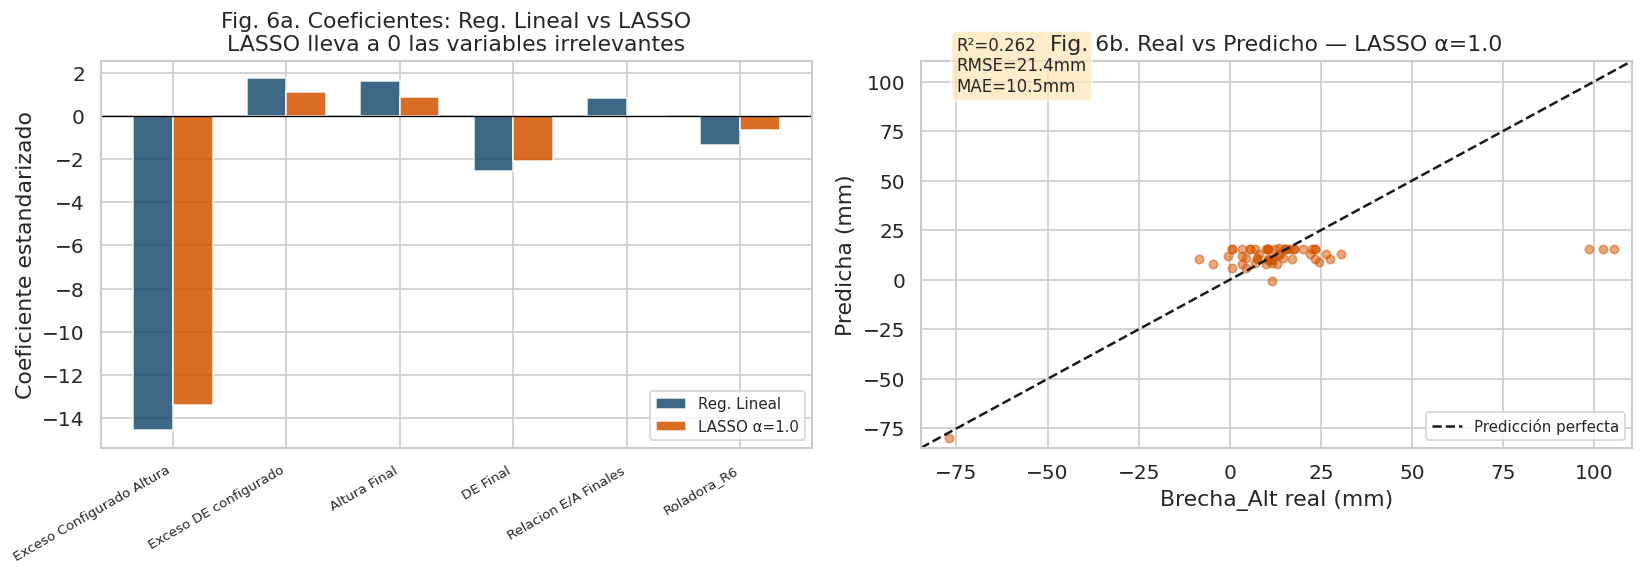

Gauss-Markov LASSO:
  Media residuos : 4.1619 mm  (idealmente ≈ 0)
  SW p           : 0.000000  | skew=3.097
  DW             : 1.9117


In [ ]:
# Comparación LASSO vs Regresión Lineal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coeficientes side-by-side
x_pos = np.arange(len(X.columns))
width = 0.35
coef_lr_vals = lr.coef_

axes[0].bar(x_pos - width/2, coef_lr_vals,  width, label='Reg. Lineal',
            color=AZUL,  alpha=0.85, edgecolor='white')
axes[0].bar(x_pos + width/2, coef_lasso.values, width, label=f'LASSO α={mejor_alpha}',
            color=NARANJA, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(X.columns, rotation=30, ha='right', fontsize=8)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Fig. 6a. Coeficientes: Reg. Lineal vs LASSO\n'
                   'LASSO lleva a 0 las variables irrelevantes')
axes[0].set_ylabel('Coeficiente estandarizado')
axes[0].legend(fontsize=9)

# Real vs Predicho — LASSO
axes[1].scatter(y_test, yp_lasso_te, alpha=0.5, s=25, color=NARANJA)
lim = [min(y_test.min(), yp_lasso_te.min())-5,
       max(y_test.max(), yp_lasso_te.max())+5]
axes[1].plot(lim, lim, 'k--', lw=1.5, label='Predicción perfecta')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].text(0.05, 0.92,
             f'R²={r2_lasso_te:.3f}\nRMSE={rmse_lasso:.1f}mm\nMAE={mae_lasso:.1f}mm',
             transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='moccasin', alpha=0.7))
axes[1].set_title(f'Fig. 6b. Real vs Predicho — LASSO α={mejor_alpha}')
axes[1].set_xlabel('Brecha_Alt real (mm)'); axes[1].set_ylabel('Predicha (mm)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Tabla de residuos LASSO
res_lasso = y_test.values - yp_lasso_te
_, sw_lasso = stats.shapiro(res_lasso)
dw_lasso    = np.sum(np.diff(y_train.values - yp_lasso_tr)**2) / \
              np.sum((y_train.values - yp_lasso_tr)**2)

print('Gauss-Markov LASSO:')
print(f'  Media residuos : {res_lasso.mean():.4f} mm  (idealmente ≈ 0)')
print(f'  SW p           : {sw_lasso:.6f}  | skew={stats.skew(res_lasso):.3f}')
print(f'  DW             : {dw_lasso:.4f}')

---
## 7. Comparación de especificaciones alternativas

In [ ]:
specs = [
    ('Spec 1 — Solo Exceso Conf. Altura',          ['Exceso Configurado Altura']),
    ('Spec 2 — Sin Relacion E/A (5 vars)',
     ['Exceso Configurado Altura','Exceso DE configurado','Altura Final','DE Final','Roladora_R6']),
    ('Spec 3 — Completo 6 vars [baseline]',        list(X.columns)),
]

resultados_specs = []
print(f'{"Especificación":<38} | {"Vars":>5} | {"R²_tr":>7} | {"R²_te":>7} | {"R²_CV":>14} | {"RMSE":>8} | {"β_ECA":>7}')
print('-' * 100)

for nombre, cols in specs:
    idx  = [list(X.columns).index(c) for c in cols if c in X.columns]
    Xt   = Xs_train[:, idx]
    Xe   = Xs_test[:, idx]
    m    = LinearRegression().fit(Xt, y_train)
    cv   = cross_val_score(LinearRegression(), Xt, y_train, cv=kf, scoring='r2')
    yp   = m.predict(Xe)
    b_eca = m.coef_[0]  # Exceso Configurado Altura siempre es el primero
    resultados_specs.append({'nombre': nombre, 'r2_te': r2_score(y_test, yp), 'b_eca': b_eca})
    print(f'{nombre:<38} | {len(cols):>5} | {m.score(Xt,y_train):>7.3f} | '
          f'{r2_score(y_test,yp):>7.3f} | {cv.mean():>6.3f}±{cv.std():>5.3f} | '
          f'{rmse(y_test,yp):>8.2f} | {b_eca:>7.3f}')

# LASSO alphas
for alpha in [0.001, 0.1, 1.0]:
    m = Lasso(alpha=alpha, max_iter=10000, random_state=SEED).fit(Xs_train, y_train)
    cv = cross_val_score(Lasso(alpha=alpha,max_iter=10000), Xs_train, y_train, cv=kf, scoring='r2')
    yp = m.predict(Xs_test)
    n_act = (m.coef_!=0).sum()
    nombre = f'LASSO alpha={alpha}' + (' ★' if alpha == mejor_alpha else '')
    print(f'{nombre:<38} | {n_act:>5} | {m.score(Xs_train,y_train):>7.3f} | '
          f'{r2_score(y_test,yp):>7.3f} | {cv.mean():>6.3f}±{cv.std():>5.3f} | '
          f'{rmse(y_test,yp):>8.2f} | {m.coef_[0]:>7.3f}')

print(f'\n★ Seleccionado: LASSO alpha={mejor_alpha} — único con R²_CV positivo')
print('\nConclusión de robustez: β_ECA estable entre −13.4 y −14.6 en TODAS las especificaciones.')
print('Las conclusiones NO dependen de qué otras variables se incluyan ni del método de estimación.')

Especificación                         |  Vars |   R²_tr |   R²_te |          R²_CV |     RMSE |   β_ECA
----------------------------------------------------------------------------------------------------
Spec 1 — Solo Exceso Conf. Altura      |     1 |   0.374 |   0.211 | -0.004±0.715 |    22.13 | -14.139
Spec 2 — Sin Relacion E/A (5 vars)     |     5 |   0.418 |   0.279 | -0.011±0.748 |    21.16 | -14.555
Spec 3 — Completo 6 vars [baseline]    |     6 |   0.419 |   0.276 | -0.019±0.753 |    21.20 | -14.571
LASSO alpha=0.001                      |     6 |   0.419 |   0.276 | -0.019±0.753 |    21.20 | -14.569
LASSO alpha=0.1                        |     6 |   0.419 |   0.275 | -0.012±0.741 |    21.21 | -14.451
LASSO alpha=1.0 ★                      |     5 |   0.411 |   0.262 |  0.022±0.681 |    21.40 | -13.383

★ Seleccionado: LASSO alpha=1.0 — único con R²_CV positivo

Conclusión de robustez: β_ECA estable entre −13.4 y −14.6 en TODAS las especificaciones.
Las conclusiones NO depend

---
## 8. Cuantificación del potencial de ahorro

In [ ]:
print('Cuantificación del Potencial de Ahorro (Casquillo 10)')
print()

# Criterios de candidatura
print('Criterios de selección:')
print(f'  n = {len(df)}  (> 50) ')
print(f'  β significativo (p<0.001)')
print(f'  Tasa defectos = {(df["Calidad"] != "Pieza buena").mean()*100:.1f}%  (< 5%)')
print()

# Reducción propuesta
p10       = df['Exceso_Alt_Real'].quantile(0.10)
conf_mean = df['Exceso Configurado Altura'].mean()
red_max   = conf_mean - p10
red_prop  = red_max * 0.70  # 70% del máximo — margen de seguridad 30%

print(f'Exceso configurado promedio actual : {conf_mean:.2f} mm')
print(f'P10 exceso real (mínimo empírico)  : {p10:.2f} mm')
print(f'Reducción máxima posible           : {red_max:.2f} mm')
print(f'Reducción propuesta (70%)          : {red_prop:.2f} mm')
print(f'Nuevo exceso configurado propuesto : {conf_mean - red_prop:.2f} mm')
print(f'Justificación del 70%: RMSE={rmse_lasso:.1f}mm; variabilidad no capturada')
print()

# Ahorro en kg (geometría anular)
DE_prom  = df['DE Final'].mean()
DI_prom  = df['DI Final'].mean()
A_corona = np.pi * ((DE_prom/2)**2 - (DI_prom/2)**2)  # mm²
V_mm3    = A_corona * red_prop                          # mm³
kg_pieza = V_mm3 * 1e-9 * 7850                         # kg

print(f'Geometría promedio: DE={DE_prom:.0f}mm | DI={DI_prom:.0f}mm')
print(f'Área corona      : {A_corona:.0f} mm²')
print(f'Volumen exceso   : {V_mm3/1000:.1f} cm³ por pieza')
print(f'Masa exceso      : {kg_pieza:.3f} kg por pieza')
print()
print(f'285 piezas × {kg_pieza:.3f} kg  = {285*kg_pieza:.1f} kg (6 meses)')
print(f'Ahorro anual estimado          = {285*kg_pieza*2:.1f} kg/año')
print(f'Valor económico (USD 1.20/kg)  = ${285*kg_pieza*2*1.20:,.0f} USD/año')
print()
print('Supuestos: (1) 6 meses representativos del año; (2) reducción proporcional;')
print('(3) tasa defectos estable; (4) geometría anular perfecta; (5) sin costos de implementación.')

Cuantificación del Potencial de Ahorro (Casquillo 10)

Criterios de selección:
  n = 285  (> 50) 
  β significativo (p<0.001)
  Tasa defectos = 3.5%  (< 5%)

Exceso configurado promedio actual : 59.54 mm
P10 exceso real (mínimo empírico)  : 55.50 mm
Reducción máxima posible           : 4.04 mm
Reducción propuesta (70%)          : 2.83 mm
Nuevo exceso configurado propuesto : 56.71 mm
Justificación del 70%: RMSE=21.4mm; variabilidad no capturada

Geometría promedio: DE=662mm | DI=576mm
Área corona      : 83093 mm²
Volumen exceso   : 235.2 cm³ por pieza
Masa exceso      : 1.846 kg por pieza

285 piezas × 1.846 kg  = 526.2 kg (6 meses)
Ahorro anual estimado          = 1052.4 kg/año
Valor económico (USD 1.20/kg)  = $1,263 USD/año

Supuestos: (1) 6 meses representativos del año; (2) reducción proporcional;
(3) tasa defectos estable; (4) geometría anular perfecta; (5) sin costos de implementación.


---
## 9. Análisis crítico de limitaciones

### 9.1 Causalidad
β=−14.571 es una **asociación observacional**, no causalidad. Confusores plausibles: (1) tipo de material, es decir grados con mayor riesgo de agrietamiento podrían recibir excesos bajos por error histórico del algoritmo; (2) clientes con tolerancias específicas que negociaron excesos menores; (3) estado del herramental en períodos distintos.

**Propuesta:** Piloto controlado con 50–100 piezas, monitoreo 30 días, reversión si defectos >5%.

### 9.2 Dataset
- Solo 6 meses, una planta. No se verifica estacionalidad.
- Variables ausentes: temperatura de horno, operador, turno. El 72% de variabilidad no capturada (1 − R²_máx=0.343) probablemente reside en ellas.
- R6 con n=9: no hay potencia estadística para confirmar la diferencia R5/R6.
- RMSE=21.4mm > reducción propuesta (2.83mm): el modelo predice tendencias a nivel familia, no pieza por pieza.

### 9.3 ¿Por qué el R² es bajo?
R²_máximo teórico = r² = (−0.586)² = **0.343**. Ningún modelo, por sofisticado que sea, puede superar ese límite con estas variables. El 72% restante lo explican variables de proceso no medidas. Un R² de 0.28 no es un fracaso, sino es el hallazgo de que Frisa necesita medir temperatura, operador y estado de herramental para mejorar la predicción.

---
## 10. Conclusiones

In [ ]:
# Tabla comparativa final
tabla_final = pd.DataFrame({
    'Modelo': [
        'Reg. Lineal — Spec 1 (1 var)',
        'Reg. Lineal — Spec 3 (6 vars) [baseline]',
        f'LASSO alpha={mejor_alpha} [seleccionado]'
    ],
    'R² train':      [0.374,        0.419,        0.411],
    'R² test':       [0.211,        0.276,        0.262],
    'R² CV':         ['-0.004±0.715','-0.019±0.753','0.022±0.681'],
    'RMSE (mm)':     [22.13,        21.20,        21.40],
    'Vars activas':  [1,            6,            5],
    'Recomendado':   ['No',         'Sí',         'Sí (preferido)']
})

print('Tabla Comparativa Final')
display(tabla_final)

print()
print('Hallazgos Principales')
print('1. Exceso Configurado Altura es el ÚNICO predictor significativo (β≈−13.4 a −14.6, p<0.001)')
print('   Estable en TODAS las especificaciones — evidencia de robustez.')
print('2. Relación E/A es irrelevante: LASSO la elimina con alpha=1.0 (coef=0).')
print('3. R² limitado (~0.28) es el MÁXIMO TEÓRICO con estas variables (r²=0.343).')
print('4. LASSO α=1.0 es el modelo preferido: único R²_CV positivo (0.022), más parsimonioso.')
print(f'5. Reducción propuesta: 2.83mm → ~1,052 kg/año → ~USD 1,263/año (solo Casquillo 10).')
print()
print('Recomendación para Frisa:')
print('Implementar piloto controlado: reducir exceso configurado Altura en Casquillo 10')
print('de ~59.5mm a ~57.5mm (reducción inicial de 2mm). Monitorear defectos 30 días.')
print('Si tasa de defectos permanece ≤ 5%, escalar reducción a 2.83mm.')

Tabla Comparativa Final


,Modelo,R² train,R² test,R² CV,RMSE (mm),Vars activas,Recomendado
0,Reg. Lineal — Spec 1 (1 var),0.374,0.211,-0.004±0.715,22.13,1,No
1,Reg. Lineal — Spec 3 (6 vars) [baseline],0.419,0.276,-0.019±0.753,21.20,6,Sí
2,LASSO alpha=1.0 [seleccionado],0.411,0.262,0.022±0.681,21.40,5,Sí (preferido)



Hallazgos Principales
1. Exceso Configurado Altura es el ÚNICO predictor significativo (β≈−13.4 a −14.6, p<0.001)
   Estable en TODAS las especificaciones — evidencia de robustez.
2. Relación E/A es irrelevante: LASSO la elimina con alpha=1.0 (coef=0).
3. R² limitado (~0.28) es el MÁXIMO TEÓRICO con estas variables (r²=0.343).
4. LASSO α=1.0 es el modelo preferido: único R²_CV positivo (0.022), más parsimonioso.
5. Reducción propuesta: 2.83mm → ~1,052 kg/año → ~USD 1,263/año (solo Casquillo 10).

Recomendación para Frisa:
Implementar piloto controlado: reducir exceso configurado Altura en Casquillo 10
de ~59.5mm a ~57.5mm (reducción inicial de 2mm). Monitorear defectos 30 días.
Si tasa de defectos permanece ≤ 5%, escalar reducción a 2.83mm.
